## Challenge: Real Quantum Teleportation

### A. Objective

Write a modified version of the quantum teleportation circuit and run it on **real IBM quantum hardware**.

### B. Task

Build a teleportation circuit with the following requirements:

1. **Initialize qubit 2** using a Hadamard gate, putting it into superposition. This is the state that will be teleported.
2. **Teleport that state to qubit 0** — note this is the **reverse direction** of the previous example, which teleported the state of qubit 0 to qubit 2.
3. At the end of the circuit, **measure only qubit 0** and save the result to a classical register.

### C. Running on Hardware

Once the circuit is built, use Qiskit to:

- Run the circuit on a **real IBM quantum computer** (not a simulator).
- Plot the measurement result on a **histogram**.

### D. Getting Started

- No starting notebook is provided for this challenge — you're building it from scratch.
- For an extra challenge, try building the solution **from memory** before referencing earlier material.
- If you get stuck, the previous teleportation example (Source → Destination direction) contains all the building blocks you'll need — you'll just need to relabel and reverse the roles of the qubits involved.

### E. Reminder from the Deferred Measurement Discussion

Since this circuit is intended to run on **real hardware**, keep the deferred measurement principle in mind: avoid applying gate instructions after a mid-circuit measurement. Where the original circuit used classically-conditioned corrections (`if_test` / `c_if`), consider whether **controlled gates** (using the not-yet-measured qubit as a control) combined with measurements deferred to the end of the circuit would be more appropriate here.

In [27]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

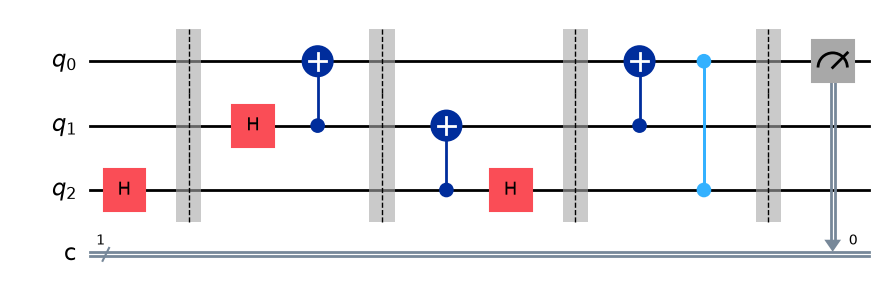

In [28]:
circuit = QuantumCircuit(3, 1)
# initialize Source's qubit
circuit.h(2)
circuit.barrier()

# Create Bell State pair.
circuit.h(1)
circuit.cx(1, 0)
circuit.barrier()

# Source performs Bell state measurement.
circuit.cx(2, 1)
circuit.h(2)
circuit.barrier()

# Source performs Bell state measurement.
circuit.cx(1, 0)
circuit.cz(2, 0)
circuit.barrier()

circuit.measure(0, 0)

circuit.draw(output='mpl')

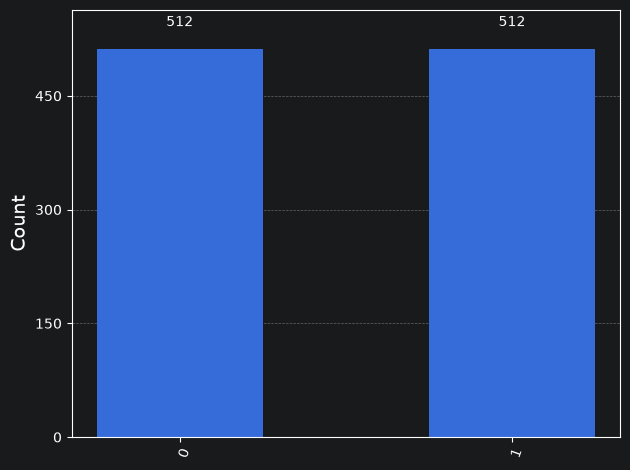

In [29]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

When the simulation finishes, we can see that each of the possible outcomes for measuring qubit zero occurred about the same number of times. This is because I initialized qubit two with a Hadamard gate then teleported that quantum state to qubit zero before measuring it.